In [ ]:
import os

import cartopy.crs as ccrs
import cmcrameri as cmc  # noqa: F401
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
from matplotlib.ticker import MaxNLocator
from unseen_awg.plotting_utils import (
    add_headers,
    add_label_to_axes,
    map_plot_without_frame_with_bounds,
)

from analyses.utils import (
    extract_datapoints_in_years,
    get_image_labeled_largest_connected_component,
    stack_to_dim,
)

In [2]:
mpl.rc_file("../../matplotlibrc")
ALPHABET = "abcdefghijk"

In [3]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

## Preparations (loading results and required data)

In [4]:
configs = {}
max_fraction_area = {}
quantiles = {}

dir_runs_reforecasts = "5e06172f_f40e9460_1e69bda9_d13ad10f"

run_wg_no_lsm = "False_b6e7334d_cd83fd6a"
run_wg_lsm = "True_b6e7334d_cd83fd6a"

base_path_no_lsm = os.path.join(
    paths["dir_results"],
    "hot_day_connected_components",
    dir_runs_reforecasts,
    run_wg_no_lsm,
)
base_path_lsm = os.path.join(
    paths["dir_results"],
    "hot_day_connected_components",
    dir_runs_reforecasts,
    run_wg_lsm,
)

max_fraction_area["no_lsm_wg"] = xr.open_dataarray(
    os.path.join(base_path_no_lsm, "max_fraction_area_wg.nc")
)
max_fraction_area["no_lsm_gt"] = xr.open_dataarray(
    os.path.join(base_path_no_lsm, "max_fraction_area_gt.nc")
)
quantiles["no_lsm_wg"] = xr.open_dataarray(
    os.path.join(base_path_no_lsm, "quantiles_wg.nc")
)
quantiles["no_lsm_gt"] = xr.open_dataarray(
    os.path.join(base_path_no_lsm, "quantiles_gt.nc")
)
with open(os.path.join(base_path_no_lsm, "params.yaml")) as file:
    configs["no_lsm"] = yaml.safe_load(file)


max_fraction_area["lsm_wg"] = xr.open_dataarray(
    os.path.join(base_path_lsm, "max_fraction_area_wg.nc")
)
max_fraction_area["lsm_gt"] = xr.open_dataarray(
    os.path.join(base_path_lsm, "max_fraction_area_gt.nc")
)
quantiles["lsm_wg"] = xr.open_dataarray(os.path.join(base_path_lsm, "quantiles_wg.nc"))
quantiles["lsm_gt"] = xr.open_dataarray(os.path.join(base_path_lsm, "quantiles_gt.nc"))
with open(os.path.join(base_path_lsm, "params.yaml")) as file:
    configs["lsm"] = yaml.safe_load(file)

In [5]:
path_data_wg = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_impact_variables_reforecasts",
    "combined-corrected_facc0e91_7d1d3d97_884a804a_3f7e331d.zarr",
)

path_era5 = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_impact_variables_era5",
    "combined_facc0e91.zarr",
)

t2m_wg = xr.open_zarr(
    path_data_wg,
    decode_timedelta=True,
)["t2m"]
t2m_wg = t2m_wg.assign_coords({"valid_time": t2m_wg.init_time + t2m_wg.lead_time})

t2m = xr.open_dataset(
    path_era5,
    decode_timedelta=True,
)["t2m"]
t2m = t2m.assign_coords({"valid_time": t2m.init_time + t2m.lead_time})

lsm = xr.open_dataset(paths["path_lsm"])["lsm"]
lsm = (
    lsm > configs["lsm"]["eval_hot_day_connected_components.lsm_threshold"]
).squeeze()

ground_truth = extract_datapoints_in_years(
    stack_to_dim(t2m),
    year_max=configs["lsm"]["eval_hot_day_connected_components.year_min"]
    + configs["lsm"]["eval_hot_day_connected_components.n_years"]
    - 1,
    year_min=configs["lsm"]["eval_hot_day_connected_components.year_min"],
).swap_dims({"datapoint": "valid_time"})

In [6]:
area_weights = np.cos(np.deg2rad(ground_truth.latitude))
area_weights.name = "area_weights"
area_weights = area_weights.expand_dims(
    {"longitude": ground_truth.longitude.data}, axis=-1
)

# normalize their sum to 1:
area_weights = area_weights / area_weights.sum()

In [7]:
def get_max_coords(max_area, dims=None):
    coords = {
        "ensemble_member": max_area.ensemble_member.isel(max_area.argmax(dims)),
        "init_time": max_area.init_time.isel(max_area.argmax(dims)),
        "lead_time": max_area.lead_time.isel(max_area.argmax(dims)),
    }
    return coords

In [8]:
coords = {}

for k, v in max_fraction_area.items():
    if "gt" in k:
        coords[k] = get_max_coords(v.squeeze(), dims=("valid_time",))
    else:
        coords[k] = get_max_coords(v.squeeze(), dims=("valid_time", "seed"))

In [9]:
images = {}

for k, v in coords.items():
    if "wg" in k:  # assume wg is always from reforecast
        images[k] = t2m_wg.sel(v).load()
    else:
        images[k] = t2m.sel(v).load()

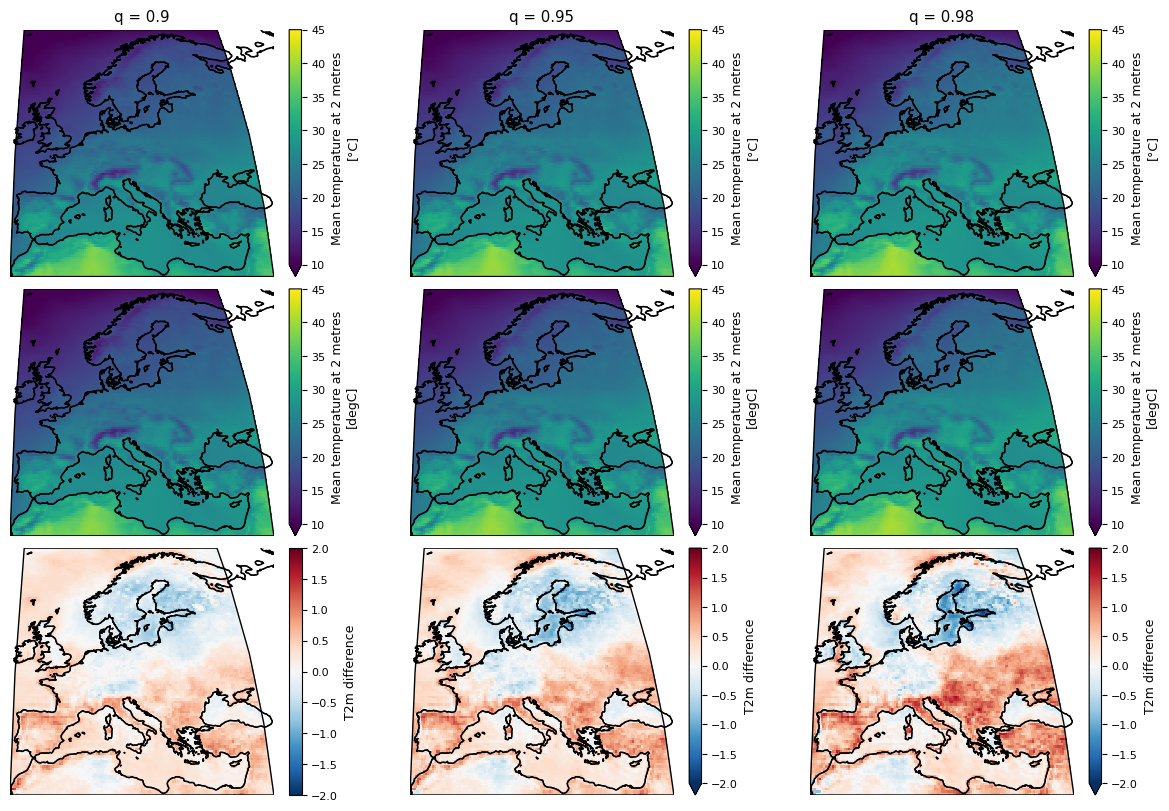

In [10]:
fig, axes = plt.subplots(
    3,
    len(images["no_lsm_gt"]["quantile"]),
    subplot_kw=dict(projection=ccrs.Robinson()),
    figsize=(12, 8),
)
for i, q in enumerate(quantiles["lsm_gt"]["quantile"]):
    map_plot_without_frame_with_bounds(
        ax=axes[0, i],
        da=quantiles["lsm_gt"].sel(quantile=q).squeeze(),
        vmin=10,
        vmax=45,
    )

    axes[0, i].coastlines()
    axes[0, i].set_title("")

    map_plot_without_frame_with_bounds(
        ax=axes[1, i],
        da=(quantiles["lsm_wg"]).sel(quantile=q).mean("seed").squeeze(),
        vmin=10,
        vmax=45,
    )
    axes[1, i].coastlines()
    axes[1, i].set_title("")

    map_plot_without_frame_with_bounds(
        ax=axes[2, i],
        da=(quantiles["lsm_wg"].mean("seed") - quantiles["lsm_gt"])
        .sel(quantile=q)
        .squeeze(),
        cmap="RdBu_r",
        cbar_kwargs={"label": "T2m difference"},
        vmin=-2,
        vmax=2,
    )

    axes[2, i].coastlines()
    axes[2, i].set_title("")
    axes[0, i].set_title(f"q = {q.data}")


plt.savefig(os.path.join(paths["dir_images"], "differences_quantiles_heat.png"))

In [11]:
binary_images = {}

for k, v in images.items():
    binary_images[k] = v > quantiles[k]
    if "no_lsm" not in k:
        binary_images[k] = binary_images[k].where(lsm, other=0)

In [12]:
im_largest_cluster = {}

for ds_name, da in binary_images.items():
    im_largest_cluster[ds_name] = xr.apply_ufunc(
        get_image_labeled_largest_connected_component,
        da,
        area_weights,
        input_core_dims=[["latitude", "longitude"], ["latitude", "longitude"]],
        output_core_dims=[["latitude", "longitude"]],
        vectorize=True,
    )

In [13]:
overall_largest_cluster_area = {}
seed_largest_cluster_area = {}
for i, (da_name, da) in enumerate(im_largest_cluster.items()):
    if "seed" in da.dims:
        stacked = max_fraction_area[da_name].stack(stacked_dim=["valid_time", "seed"])
        argmax_indices = stacked.argmax(dim="stacked_dim")
        seed_indices = stacked.seed.isel(stacked_dim=argmax_indices)
        overall_largest_cluster_area[da_name] = stacked.max(dim="stacked_dim")
    else:
        overall_largest_cluster_area[da_name] = max_fraction_area[da_name].max(
            dim="valid_time"
        )

no_lsm_wg
no_lsm_gt
lsm_wg
lsm_gt


/tmp/ipykernel_1191099/3175866384.py:128: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


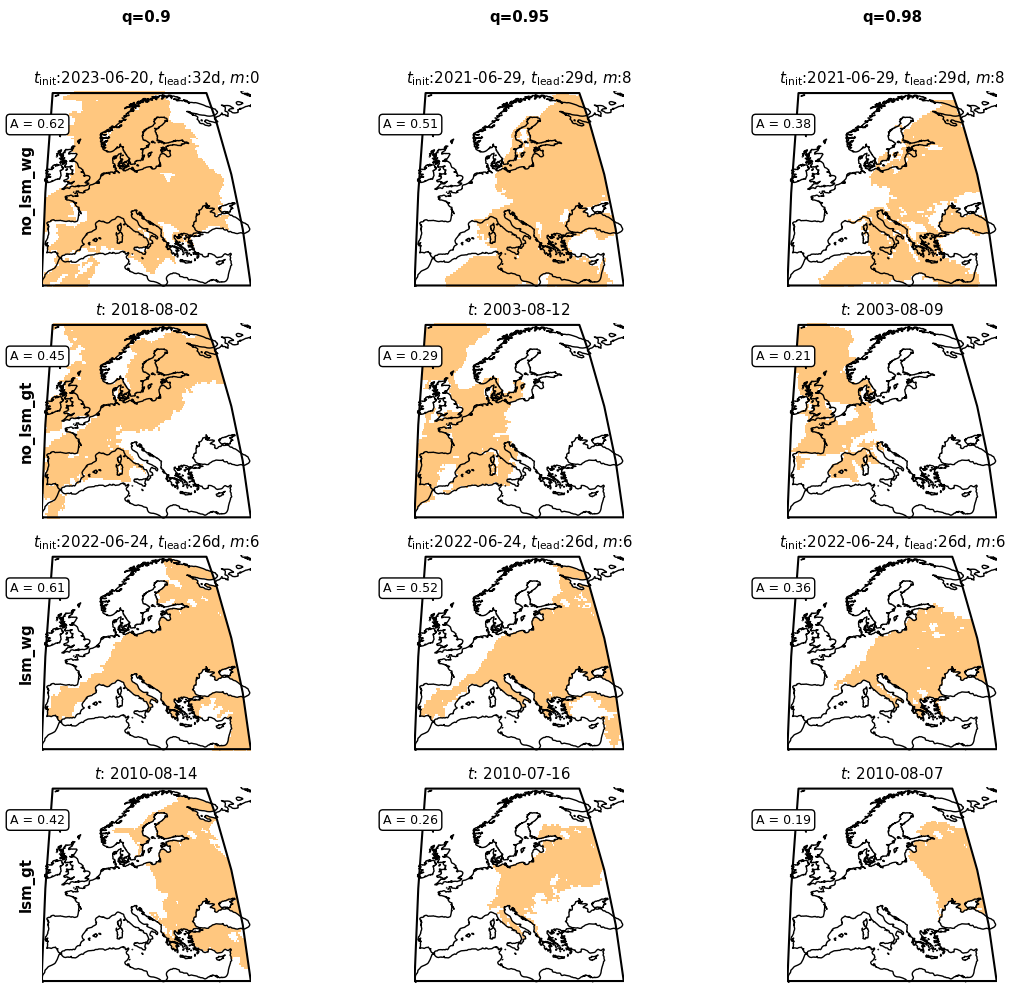

In [14]:
fig, axes = plt.subplots(
    len(im_largest_cluster.keys()),
    len(im_largest_cluster["lsm_gt"]["quantile"]),
    subplot_kw=dict(projection=ccrs.Robinson()),
    figsize=(12, 10),
)

cmap = mpl.colormaps.get_cmap("copper")
cmap.set_under(alpha=0)
cmap.set_over(alpha=1)

latitudes = quantiles["lsm_gt"].latitude
longitudes = quantiles["lsm_gt"].longitude

dlat = latitudes[1] - latitudes[0]
dlon = longitudes[1] - longitudes[0]

lat_min = latitudes.min() - dlat / 2
lat_max = latitudes.max() + dlat / 2
lon_min = longitudes.min() - dlon / 2
lon_max = longitudes.max() + dlon / 2

for i, (da_name, da) in enumerate(im_largest_cluster.items()):
    print(da_name)
    for j, q in enumerate(da["quantile"]):
        if "gt" in da_name:
            fraction_area_covered = (
                max_fraction_area[da_name]
                .max(("valid_time",))
                .squeeze()
                .sel(quantile=q)
                .data.item()
            )
        else:
            fraction_area_covered = (
                max_fraction_area[da_name]
                .max(("seed", "valid_time"))
                .squeeze()
                .sel(quantile=q)
                .data.item()
            )

        if "no_lsm" in da_name:
            pass
        else:
            fraction_area_covered /= area_weights.where(
                lsm
            ).sum()  # if applying LSM, display as fraction of land area
        if "gt" in da_name:
            da.sel(quantile=q.data).plot(
                ax=axes[i, j],
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                vmin=0.5,
                vmax=1,
                add_colorbar=False,
            )
        else:
            da.sel(quantile=q.data).isel(seed=seed_indices.sel(quantile=q.data)).plot(
                ax=axes[i, j],
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                vmin=0.5,
                vmax=1,
                add_colorbar=False,
            )
        # it =
        if "gt" in da_name:
            it = coords[da_name]["init_time"].sel(quantile=q).squeeze()
            lt = coords[da_name]["lead_time"].sel(quantile=q).squeeze()
            axes[i, j].set_title(
                r"$t$" + f": {np.datetime_as_string((it + lt).squeeze(), unit='D')}"
            )
        else:
            it = (
                coords[da_name]["init_time"]
                .sel(quantile=q)
                .squeeze()
                .values.astype("datetime64[ns]")
            )
            lt = (
                coords[da_name]["lead_time"]
                .sel(quantile=q)
                .squeeze()
                .values.astype("timedelta64[ns]")
            )
            em = coords[da_name]["ensemble_member"].sel(quantile=q).squeeze().values
            axes[i, j].set_title(
                r"$t_\mathrm{init}$:"
                + np.datetime_as_string(it.squeeze(), unit="D")
                + r", $t_\mathrm{lead}$:"
                + f"{int(lt / np.timedelta64(1, 'D'))}"
                + r"d, $m$:"
                + f"{em}"
            )
        axes[i, j].coastlines()

        axes[i, j].plot(
            [lon_min, lon_max, lon_max, lon_min, lon_min],
            [lat_min, lat_min, lat_max, lat_max, lat_min],
            color="black",
            transform=ccrs.PlateCarree(),  # remove this line to get straight lines
        )

        for spine in axes[i, j].spines.values():
            spine.set_visible(False)

        transform = ccrs.PlateCarree()._as_mpl_transform(axes[i, j])
        axes[i, j].annotate(
            f"A = {fraction_area_covered:.2f}",
            xy=(-21.9408, 64.1470),
            xycoords=transform,
            ha="left",
            va="center",
            bbox=dict(boxstyle="round", edgecolor="black", facecolor="white"),
        )

font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    row_headers=[k for k in im_largest_cluster.keys()],
    col_headers=[f"q={q.data}" for q in da["quantile"]],
    col_pad=50,
    **font_kwargs,
)

plt.tight_layout()

plt.show()

/tmp/ipykernel_1191099/4010923710.py:131: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


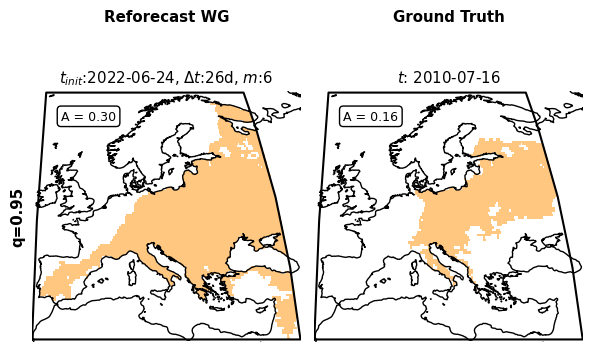

In [15]:
fig, axes = plt.subplots(
    1,
    2,
    subplot_kw=dict(projection=ccrs.Robinson()),
)

fig.set_size_inches((6, 4))

cmap = mpl.colormaps.get_cmap("copper")
cmap.set_under(alpha=0)
cmap.set_over(alpha=1)

latitudes = quantiles["lsm_gt"].latitude
longitudes = quantiles["lsm_gt"].longitude

dlat = latitudes[1] - latitudes[0]
dlon = longitudes[1] - longitudes[0]

lat_min = latitudes.min() - dlat / 2
lat_max = latitudes.max() + dlat / 2
lon_min = longitudes.min() - dlon / 2
lon_max = longitudes.max() + dlon / 2

# for i, (da_name, da) in enumerate(im_largest_cluster.items()):
#     print(da_name)
# for j, q in enumerate(da["quantile"]):

q = im_largest_cluster["lsm_gt"]["quantile"].sel(quantile=0.95)
j = 0

subset_im_largest_cluster = {
    k: v for (k, v) in im_largest_cluster.items() if k in ["lsm_gt", "lsm_wg"]
}

for i, (da_name, da) in enumerate(subset_im_largest_cluster.items()):
    if "gt" in da_name:
        fraction_area_covered = (
            max_fraction_area[da_name]
            .max(("valid_time",))
            .squeeze()
            .sel(quantile=q)
            .data.item()
        )
    else:
        fraction_area_covered = (
            max_fraction_area[da_name]
            .max(("seed", "valid_time"))
            .squeeze()
            .sel(quantile=q)
            .data.item()
        )
    if "gt" in da_name:
        da.sel(quantile=q.data).plot(
            ax=axes[i],
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=0.5,
            vmax=1,
            add_colorbar=False,
        )
    else:
        da.sel(quantile=q.data).isel(seed=seed_indices.sel(quantile=q.data)).plot(
            ax=axes[i],
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=0.5,
            vmax=1,
            add_colorbar=False,
        )
    # it =
    if "gt" in da_name:
        it = coords[da_name]["init_time"].sel(quantile=q).squeeze()
        lt = coords[da_name]["lead_time"].sel(quantile=q).squeeze()
        axes[i].set_title(
            r"$t$" + f": {np.datetime_as_string((it + lt).squeeze(), unit='D')}"
        )
    else:
        it = (
            coords[da_name]["init_time"]
            .sel(quantile=q)
            .squeeze()
            .values.astype("datetime64[ns]")
        )
        lt = (
            coords[da_name]["lead_time"]
            .sel(quantile=q)
            .squeeze()
            .values.astype("timedelta64[ns]")
        )
        em = coords[da_name]["ensemble_member"].sel(quantile=q).squeeze().values
        axes[i].set_title(
            r"$t_{init}$:"
            + np.datetime_as_string(it.squeeze(), unit="D")
            + r", $\Delta t$:"
            + f"{int(lt / np.timedelta64(1, 'D'))}"
            + r"d, $m$:"
            + f"{em}"
        )
    axes[i].coastlines()

    axes[i].plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        color="black",
        transform=ccrs.PlateCarree(),  # remove this line to get straight lines
    )

    for spine in axes[i].spines.values():
        spine.set_visible(False)

    transform = ccrs.PlateCarree()._as_mpl_transform(axes[i])
    axes[i].annotate(
        f"A = {fraction_area_covered:.2f}",
        xy=(-5.9408, 67.1470),
        xycoords=transform,
        ha="left",
        va="center",
        bbox=dict(boxstyle="round", edgecolor="black", facecolor="white"),
    )

font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    col_headers=["Reforecast WG", "Ground Truth"],
    row_headers=[f"q={q.data}"],
    col_pad=50,
    **font_kwargs,
)

plt.tight_layout()

plt.savefig(os.path.join(paths["dir_images"], "hot_day_map_reduced.png"))

plt.show()

In [16]:
max_fraction_area["lsm_wg"].argmax(("seed", "valid_time"))

{'seed': <xarray.DataArray 't2m' (quantile: 3, probability_model: 1, sigma: 1,
                          blocksize: 1)> Size: 24B
 array([[[[115]]],
 
 
        [[[115]]],
 
 
        [[[115]]]])
 Coordinates:
   * quantile           (quantile) float64 24B 0.9 0.95 0.98
   * probability_model  (probability_model) <U14 56B 'NoRestrictions'
   * sigma              (sigma) float64 8B 2.5
   * blocksize          (blocksize) int64 8B 30
     number             int64 8B 0
     expver             <U4 16B '0001'
 Attributes:
     units:          degC
     standard_name:  air_temperature
     cell_methods:   lead_time: mean
     long_name:      Mean temperature at 2 metres,
 'valid_time': <xarray.DataArray 't2m' (quantile: 3, probability_model: 1, sigma: 1,
                          blocksize: 1)> Size: 24B
 array([[[[878]]],
 
 
        [[[878]]],
 
 
        [[[878]]]])
 Coordinates:
   * quantile           (quantile) float64 24B 0.9 0.95 0.98
   * probability_model  (probability_model) <U14 

## Are our WG connected component sizes statistically similar to ERA5?

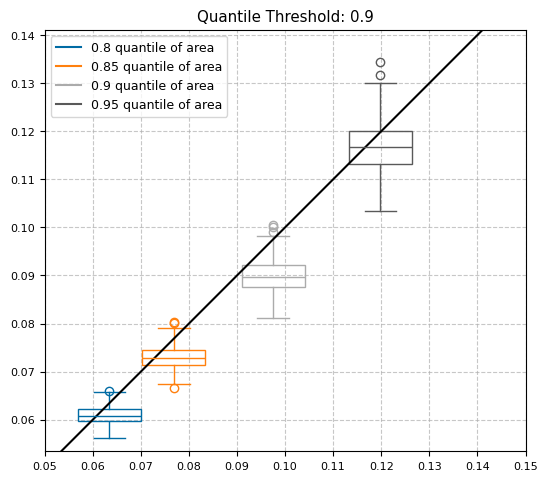

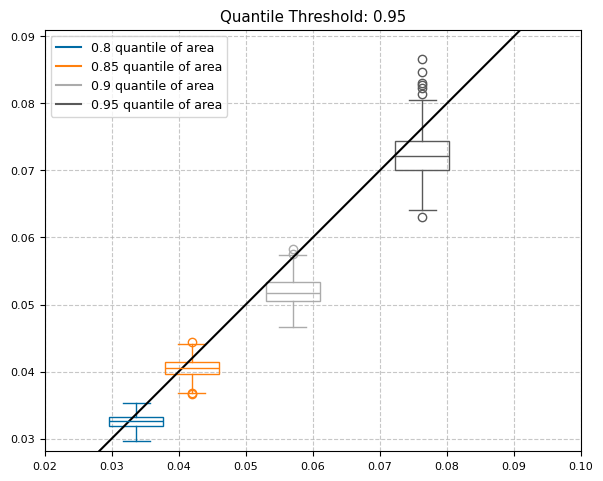

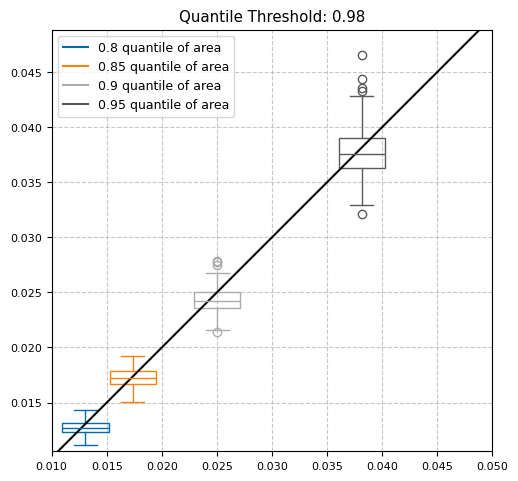

In [17]:
area_quantiles = np.linspace(0.8, 1, 5)[:-1]

for qt in max_fraction_area["lsm_wg"]["quantile"]:
    quantiles_area_wg = (
        max_fraction_area["lsm_wg"]
        .rename({"quantile": "quantile_threshold"})
        .sel(quantile_threshold=qt)
        .quantile(area_quantiles, "valid_time")
        .squeeze()
    )
    quantiles_area_gt = (
        max_fraction_area["lsm_gt"]
        .rename({"quantile": "quantile_threshold"})
        .sel(quantile_threshold=qt)
        .quantile(area_quantiles, "valid_time")
        .squeeze()
    )

    fig = plt.figure()
    ax = plt.gca()

    x = quantiles_area_gt.squeeze()

    width = 0.98 * np.amin(
        (x.isel(quantile=slice(1, None)).data - x.isel(quantile=slice(None, -1)).data)
    )

    ys = quantiles_area_wg

    bp = plt.boxplot(ys.transpose(), positions=x, widths=width, patch_artist=True)

    # Define colors for each boxplot
    prop_cycle = plt.rcParams["axes.prop_cycle"]
    colors = prop_cycle.by_key()["color"]  # Or use a custom list of colors

    # Apply colors to each boxplot and collect legend handles
    legend_handles = []
    for i, (box, color) in enumerate(zip(bp["boxes"], colors)):
        # Set edge colors for all elements
        plt.setp(bp["boxes"][i], edgecolor=color, facecolor="none")
        plt.setp(bp["whiskers"][i * 2 : i * 2 + 2], color=color)
        plt.setp(bp["caps"][i * 2 : i * 2 + 2], color=color)
        plt.setp(bp["medians"][i], color=color)
        plt.setp(bp["fliers"][i], markeredgecolor=color, markerfacecolor="none")

        # Create legend handle
        legend_handles.append(
            plt.Line2D(
                [0], [0], color=color, label=f"{area_quantiles[i]:g} quantile of area"
            )
        )  # Customize labels

    vmax = max(x.max(), ys.max()) * 1.05
    vmin = min(x.min(), ys.min()) * 0.95
    plt.plot(np.linspace(0, vmax, 2), np.linspace(0, vmax, 2), c="k")
    ax.set_aspect("equal")
    plt.xlim(vmin, vmax)
    plt.ylim(vmin, vmax)

    ax.set_xticks(ax.get_yticks())
    ax.set_xticklabels(ax.get_yticklabels())  # Format labels
    plt.title(f"Quantile Threshold: {qt:g}")
    ax.legend(handles=legend_handles, loc="best")

<>:209: SyntaxWarning: invalid escape sequence '\m'
<>:209: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1191099/2198872555.py:209: SyntaxWarning: invalid escape sequence '\m'
  axes[-1, k].set_xlabel("$Q_A$ $\mathrm{ERA5}_{2003-2023}$")


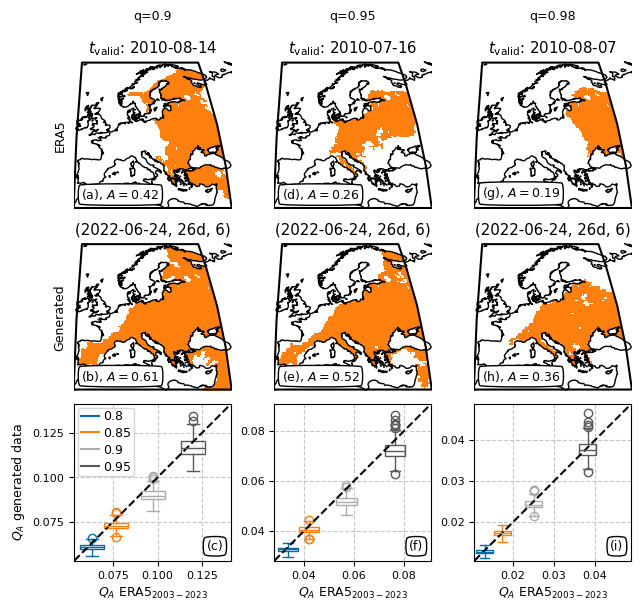

In [18]:
# Combined Figure:

rename_dict = {"lsm_wg": "Generated", "lsm_gt": "ERA5"}

sel_max_fraction_area = {
    rename_dict[name]: dataset
    for (name, dataset) in max_fraction_area.items()
    if name in rename_dict.keys()
}

sel_im_largest_cluster = {
    rename_dict[name]: dataset
    for (name, dataset) in im_largest_cluster.items()
    if name in rename_dict.keys()
}

sel_coords = {
    rename_dict[name]: values
    for (name, values) in coords.items()
    if name in rename_dict.keys()
}

n_rows = len(sel_max_fraction_area.keys()) + 1
n_cols = len(sel_max_fraction_area["Generated"]["quantile"])

fig = plt.figure()

fig.set_figheight(6)

cmap = mpl.colors.ListedColormap("C1")
cmap.set_under(alpha=0)
cmap.set_over(alpha=1)

axes = np.empty((n_rows, n_cols), dtype=object)

# Create GeoAxes for all rows except the last
for row in range(n_rows - 1):
    for col in range(n_cols):
        axes[row, col] = fig.add_subplot(
            n_rows, n_cols, row * n_cols + col + 1, projection=ccrs.Robinson()
        )

# Create regular Axes for the last row
for col in range(n_cols):
    axes[-1, col] = fig.add_subplot(n_rows, n_cols, (n_rows - 1) * n_cols + col + 1)


latitudes = quantiles["lsm_gt"].latitude
longitudes = quantiles["lsm_gt"].longitude

dlat = latitudes[1] - latitudes[0]
dlon = longitudes[1] - longitudes[0]

lat_min = latitudes.min() - dlat / 2
lat_max = latitudes.max() + dlat / 2
lon_min = longitudes.min() - dlon / 2
lon_max = longitudes.max() + dlon / 2


for i, (da_name) in enumerate(["ERA5", "Generated"]):
    da = sel_im_largest_cluster[da_name]
    for j, q in enumerate(da["quantile"]):
        if "ERA5" in da_name:
            fraction_area_covered = (
                sel_max_fraction_area[da_name]
                .max(("valid_time",))
                .squeeze()
                .sel(quantile=q)
                .data.item()
            )
        else:
            fraction_area_covered = (
                sel_max_fraction_area[da_name]
                .max(("seed", "valid_time"))
                .squeeze()
                .sel(quantile=q)
                .data.item()
            )

        if "no_lsm" in da_name:
            pass
        else:
            fraction_area_covered /= area_weights.where(
                lsm
            ).sum()  # if applying LSM, display as fraction of land area

        if "ERA5" in da_name:
            m = da.sel(quantile=q.data).plot(
                ax=axes[i, j],
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                vmin=0.5,
                vmax=1,
                add_colorbar=False,
            )
            m.set_rasterized(True)
        else:
            m = (
                da.sel(quantile=q.data)
                .isel(seed=seed_indices.sel(quantile=q.data))
                .plot(
                    ax=axes[i, j],
                    transform=ccrs.PlateCarree(),
                    cmap=cmap,
                    vmin=0.5,
                    vmax=1,
                    add_colorbar=False,
                )
            )
            m.set_rasterized(True)
        # it =
        if "ERA5" in da_name:
            it = sel_coords[da_name]["init_time"].sel(quantile=q).squeeze()
            lt = sel_coords[da_name]["lead_time"].sel(quantile=q).squeeze()
            axes[i, j].set_title(
                r"$t_\mathrm{valid}$"
                + f": {np.datetime_as_string((it + lt).squeeze(), unit='D')}"
            )
        else:
            it = (
                sel_coords[da_name]["init_time"]
                .sel(quantile=q)
                .squeeze()
                .values.astype("datetime64[ns]")
            )
            lt = (
                sel_coords[da_name]["lead_time"]
                .sel(quantile=q)
                .squeeze()
                .values.astype("timedelta64[ns]")
            )
            em = sel_coords[da_name]["ensemble_member"].sel(quantile=q).squeeze().values
            axes[i, j].set_title(
                rf"({np.datetime_as_string((it).squeeze(), unit='D')}, {int(lt / np.timedelta64(1, 'D'))}d, {em})"
            )
        axes[i, j].coastlines()

        axes[i, j].plot(
            [lon_min, lon_max, lon_max, lon_min, lon_min],
            [lat_min, lat_min, lat_max, lat_max, lat_min],
            color="black",
            transform=ccrs.PlateCarree(),  # remove this line to get straight lines
        )

        for spine in axes[i, j].spines.values():
            spine.set_visible(False)

        transform = ccrs.PlateCarree()._as_mpl_transform(axes[i, j])

        add_label_to_axes(
            axes[i, j],
            label=f"({ALPHABET[i + n_rows * j]}), $A = {fraction_area_covered:.2f}$",
            va="bottom",
            ha="left",
            ax_xpos=0.05,
            ax_ypos=0.05,
            edgecolor="k",
        )


# Q--Q plots
for k, qt in enumerate(max_fraction_area["lsm_wg"]["quantile"]):
    quantiles_area_wg = (
        max_fraction_area["lsm_wg"]
        .rename({"quantile": "quantile_threshold"})
        .sel(quantile_threshold=qt)
        .quantile(area_quantiles, "valid_time")
        .squeeze()
    )
    quantiles_area_gt = (
        max_fraction_area["lsm_gt"]
        .rename({"quantile": "quantile_threshold"})
        .sel(quantile_threshold=qt)
        .quantile(area_quantiles, "valid_time")
        .squeeze()
    )

    x = quantiles_area_gt.squeeze()

    width = 0.98 * np.amin(
        (x.isel(quantile=slice(1, None)).data - x.isel(quantile=slice(None, -1)).data)
    )

    ys = quantiles_area_wg

    bp = axes[-1, k].boxplot(
        ys.transpose(), positions=x, widths=width, patch_artist=True
    )

    # Define colors for each boxplot
    prop_cycle = plt.rcParams["axes.prop_cycle"]
    colors = prop_cycle.by_key()["color"]  # Or use a custom list of colors

    # Apply colors to each boxplot and collect legend handles
    legend_handles = []
    for i, (box, color) in enumerate(zip(bp["boxes"], colors)):
        # Set edge colors for all elements
        plt.setp(bp["boxes"][i], edgecolor=color, facecolor="none")
        plt.setp(bp["whiskers"][i * 2 : i * 2 + 2], color=color)
        plt.setp(bp["caps"][i * 2 : i * 2 + 2], color=color)
        plt.setp(bp["medians"][i], color=color)
        plt.setp(bp["fliers"][i], markeredgecolor=color, markerfacecolor="none")

        # Create legend handle
        legend_handles.append(
            plt.Line2D([0], [0], color=color, label=f"${area_quantiles[i]:g}$")
        )  # Customize labels

    axes[-1, k].set_xlabel("$Q_A$ $\mathrm{ERA5}_{2003-2023}$")
    if k == 0:
        axes[-1, k].set_ylabel("$Q_A$ generated data")
        axes[-1, k].legend(
            handles=legend_handles,
            loc="best",
            labelspacing=0.3,  # vertical space between entries
            handlelength=1.5,  # length of legend handles
            handletextpad=0.3,  # space between handle and text
            borderpad=0.2,  # padding inside legend border
            columnspacing=1.0,  # space between columns
            borderaxespad=0.3,  # padding between axes and legend
        )

    vmax = max(x.max(), ys.max()) * 1.05
    vmin = min(x.min(), ys.min()) * 0.95

    axes[-1, k].set_aspect("equal", adjustable="box")

    axes[-1, k].set_xlim(vmin, vmax)
    axes[-1, k].set_ylim(vmin, vmax)

    axes[-1, k].plot(
        np.linspace(vmin, vmax, 2),
        np.linspace(vmin, vmax, 2),
        c="k",
        linestyle="dashed",
    )

    n_ticks = 3  # Adjust as needed

    locator = MaxNLocator(nbins=4, prune="both")
    # Use the x-axis range to calculate ticks
    ticks = locator.tick_values(vmin, vmax)
    # Apply the same ticks to both axes
    axes[-1, k].set_xticks(ticks)
    axes[-1, k].set_yticks(ticks)
    axes[-1, k].set_xticklabels(axes[-1, k].get_yticklabels())

    add_label_to_axes(
        axes[-1, k],
        label=f"({ALPHABET[n_rows - 1 + n_rows * k]})",
        va="bottom",
        ha="right",
        ax_xpos=0.95,
        ax_ypos=0.05,
        edgecolor="k",
    )

font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    col_headers=[f"q={q.data}" for q in max_fraction_area["lsm_wg"]["quantile"]],
    row_headers=["ERA5", "Generated"] + [""],
    col_pad=30,
    # fontsize="large"
    # row_pad=10,
)


plt.savefig(os.path.join(paths["dir_images"], "hot_day_combined.pdf"), dpi=300)

plt.show()

In [19]:
[k for k in sel_im_largest_cluster.keys()]

['Generated', 'ERA5']

In [20]:
[f"q={q.data}" for q in da["quantile"]]

['q=0.9', 'q=0.95', 'q=0.98']

## how many members have a heatwave with a larger extent than ERA5?

In [21]:
overall_max_gt = max_fraction_area["lsm_gt"].max("valid_time").squeeze()
max_fraction_area_wg = max_fraction_area["lsm_wg"].squeeze()

overall_max_gt_no_lsm = max_fraction_area["no_lsm_gt"].max("valid_time").squeeze()
max_fraction_area_wg_no_lsm = max_fraction_area["no_lsm_wg"].squeeze()

In [22]:
(max_fraction_area_wg > overall_max_gt).any(dim=("valid_time",)).mean("seed")

<xarray.DataArray 't2m' (quantile: 3)> Size: 24B
array([0.458, 0.872, 0.772])
Coordinates:
  * quantile           (quantile) float64 24B 0.9 0.95 0.98
    probability_model  <U14 56B 'NoRestrictions'
    sigma              float64 8B 2.5
    blocksize          int64 8B 30
    number             int64 8B 0
    expver             <U4 16B '0001'
Attributes:
    standard_name:  air_temperature
    cell_methods:   lead_time: mean
    long_name:      Mean temperature at 2 metres
    regrid_method:  bilinear

In [23]:
(max_fraction_area_wg_no_lsm > overall_max_gt_no_lsm).any(dim=("valid_time",)).mean(
    "seed"
)

<xarray.DataArray 't2m' (quantile: 3)> Size: 24B
array([0.39 , 0.644, 0.39 ])
Coordinates:
  * quantile           (quantile) float64 24B 0.9 0.95 0.98
    probability_model  <U14 56B 'NoRestrictions'
    sigma              float64 8B 2.5
    blocksize          int64 8B 30
Attributes:
    standard_name:  air_temperature
    cell_methods:   lead_time: mean
    long_name:      Mean temperature at 2 metres
    regrid_method:  bilinear

In [24]:
# how many events with a larger extent can we find?
print(overall_max_gt["quantile"].data)
print((max_fraction_area_wg > overall_max_gt).mean(dim=("valid_time", "seed")).data)
print((max_fraction_area_wg > overall_max_gt).sum(dim=("valid_time", "seed")).data)

[0.9  0.95 0.98]
[0.00055694 0.00204141 0.00152692]
[ 538 1972 1475]


In [25]:
# how many events with a larger extent can we find? (no lsm)
print(overall_max_gt["quantile"].data)
print(
    (max_fraction_area_wg_no_lsm > overall_max_gt_no_lsm)
    .mean(dim=("valid_time", "seed"))
    .data
)
print(
    (max_fraction_area_wg_no_lsm > overall_max_gt_no_lsm)
    .sum(dim=("valid_time", "seed"))
    .data
)

[0.9  0.95 0.98]
[0.00058799 0.00101035 0.00045031]
[568 976 435]


In [26]:
overall_max_gt_no_lsm

<xarray.DataArray 't2m' (quantile: 3)> Size: 24B
array([0.45024554, 0.28836407, 0.20648664])
Coordinates:
  * quantile  (quantile) float64 24B 0.9 0.95 0.98
Attributes:
    long_name:      Mean temperature at 2 metres
    standard_name:  air_temperature
    regrid_method:  bilinear
    units:          °C
    cell_methods:   lead_time: mean

In [27]:
max_fraction_area_wg_no_lsm.max(("seed", "valid_time"))

<xarray.DataArray 't2m' (quantile: 3)> Size: 24B
array([0.62004683, 0.50901906, 0.38303475])
Coordinates:
  * quantile           (quantile) float64 24B 0.9 0.95 0.98
    probability_model  <U14 56B 'NoRestrictions'
    sigma              float64 8B 2.5
    blocksize          int64 8B 30
Attributes:
    units:          degC
    standard_name:  air_temperature
    cell_methods:   lead_time: mean
    long_name:      Mean temperature at 2 metres